<div style="background-color: #050a30; padding: 20px; border-radius: 10px;">
<h2 style="color: white; margin: 0; font-weight: bold;">¿Cuáles son los perfiles demográficos que muestran más propensión a contratar productos financieros?</h2>
</div>


--- 
## 1. Carga de datos limpios
---

In [3]:
import pandas as pd
import numpy as np
import plotly.io as pio
import plotly.express as px
import plotly.graph_objects as go

# Configuración de estilo DarkMode (igual que el reporte)
pio.templates.default = "plotly_dark"
pio.templates["custom"] = pio.templates["plotly_dark"]
pio.templates["custom"].layout.paper_bgcolor = "#050a30"
pio.templates["custom"].layout.plot_bgcolor  = "#050a30"
pio.templates.default = "custom"

df = pd.read_csv(r"C:\Users\HP\ProjecteData\Equip_30\Data\05-25-2026\Bank_Marketing_Clean-25_May.csv")
df.head()



,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,1,59,admin.,married,secondary,0,2343,1,0,unknown,5,may,1042,1,-1,0,no_pcampaign,1
1,2,56,admin.,married,secondary,0,45,0,0,unknown,5,may,1467,1,-1,0,no_pcampaign,1
2,3,41,technician,married,secondary,0,1270,1,0,unknown,5,may,1389,1,-1,0,no_pcampaign,1
3,4,55,services,married,secondary,0,2476,1,0,unknown,5,may,579,1,-1,0,no_pcampaign,1
4,5,54,admin.,married,tertiary,0,184,0,0,unknown,5,may,673,2,-1,0,no_pcampaign,1


--- 
## 2. Creación de nuevas variables
---

In [4]:
# Crear la columna total_products_bought como la suma de deposit, housing y loan
df['total_products_bought'] = (df['deposit'] + df['housing'] + df['loan']).astype(int)

# Verificar la creación de la columna
print("Primeras filas con la nueva columna:")
print(df[['deposit', 'housing', 'loan', 'total_products_bought']].head())

df.head()

Primeras filas con la nueva columna:
   deposit  housing  loan  total_products_bought
0        1        1     0                      2
1        1        0     0                      1
2        1        1     0                      2
3        1        1     0                      2
4        1        0     0                      1


,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit,total_products_bought
0,1,59,admin.,married,secondary,0,2343,1,0,unknown,5,may,1042,1,-1,0,no_pcampaign,1,2
1,2,56,admin.,married,secondary,0,45,0,0,unknown,5,may,1467,1,-1,0,no_pcampaign,1,1
2,3,41,technician,married,secondary,0,1270,1,0,unknown,5,may,1389,1,-1,0,no_pcampaign,1,2
3,4,55,services,married,secondary,0,2476,1,0,unknown,5,may,579,1,-1,0,no_pcampaign,1,2
4,5,54,admin.,married,tertiary,0,184,0,0,unknown,5,may,673,2,-1,0,no_pcampaign,1,1


--- 
## 3. Selección de variables demográicas
---

In [5]:
# Crear una copia con variables demográficas
variables_demograficas=['age','job','marital','education']

df_demo = df[variables_demograficas].copy()

# df_demo.info()
# df_demo.head(5000)
# df_demo.isnull().sum()
df_demo.shape

#df_demo

(10642, 4)

--- 
## 4. Preparación para modelado
---

In [6]:
df.head()

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit,total_products_bought
0,1,59,admin.,married,secondary,0,2343,1,0,unknown,5,may,1042,1,-1,0,no_pcampaign,1,2
1,2,56,admin.,married,secondary,0,45,0,0,unknown,5,may,1467,1,-1,0,no_pcampaign,1,1
2,3,41,technician,married,secondary,0,1270,1,0,unknown,5,may,1389,1,-1,0,no_pcampaign,1,2
3,4,55,services,married,secondary,0,2476,1,0,unknown,5,may,579,1,-1,0,no_pcampaign,1,2
4,5,54,admin.,married,tertiary,0,184,0,0,unknown,5,may,673,2,-1,0,no_pcampaign,1,1


In [7]:
# Revisar valores únicos de variables categóricas

for col in ['job', 'marital', 'education']:
    print(col)
    print(df_demo[col].value_counts())
    print()

job
job
management       2515
blue-collar      1830
technician       1737
admin.           1279
services          881
retired           755
self-employed     388
student           354
unemployed        338
entrepreneur      308
housemaid         257
Name: count, dtype: int64

marital
marital
married     6035
single      3374
divorced    1233
Name: count, dtype: int64

education
education
secondary    5696
tertiary     3527
primary      1419
Name: count, dtype: int64



In [8]:
#  Escalar variable numérica

from sklearn.preprocessing import StandardScaler

#  Escalado
scaler = StandardScaler()
df_demo['age_scaled'] = scaler.fit_transform(df_demo[['age']])

# Dataset final
df_kproto = df_demo[['age_scaled', 'job', 'marital', 'education']].copy()

# Conversión
X = df_kproto.to_numpy()

# Variables categóricas
categorical_columns = [1, 2, 3]
df_kproto.dtypes

age_scaled    float64
job            object
marital        object
education      object
dtype: object

--- 
## 5. Modelado
---

In [9]:
# Probar diferentes números de clusters
from kmodes.kprototypes import KPrototypes

costs = []

for k in range(2, 8):

    print(f'Probando k = {k}')

    kproto = KPrototypes(
        n_clusters=k,
        init='Cao',
        max_iter=20,
        random_state=42,
        verbose=0
    )

    clusters = kproto.fit_predict(
        X,
        categorical=categorical_columns
    )

    costs.append(kproto.cost_)

Probando k = 2
Probando k = 3
Probando k = 4
Probando k = 5
Probando k = 6
Probando k = 7


--- 
## 6. Grafico método del codo
---

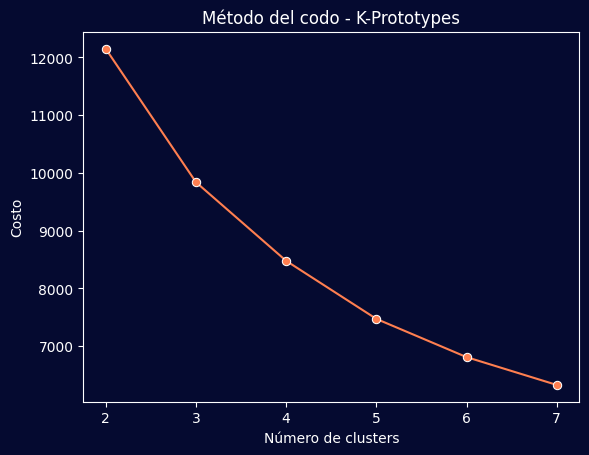

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Aplicar estilo oscuro de Matplotlib
plt.style.use('dark_background')

sns.lineplot(
    x=range(2, 8),
    y=costs,
    marker='o',
    color='coral' # Color similar al del reporte
)

plt.xlabel('Número de clusters')
plt.ylabel('Costo')
plt.title('Método del codo - K-Prototypes')

# Forzar color de fondo de la figura para que coincida con Plotly
plt.gcf().set_facecolor('#050a30')
plt.gca().set_facecolor('#050a30')

plt.show()


K_optimo = 4

---
## 7. Entrenamiento modelo final
---

In [11]:
from kmodes.kprototypes import KPrototypes

kproto_final = KPrototypes(
    n_clusters= 4,
    init='Cao',
    max_iter=20,
    random_state=42
)
clusters = kproto_final.fit_predict(
    X,
    categorical=categorical_columns
)



In [12]:
# Agregar clusters al dataframe
df_demo['cluster'] = clusters

In [13]:
# Contar clientes por clusters

df_demo['cluster'].value_counts()
df['deposit'].unique()

array([1, 0])

In [14]:
#Variable objetivo
df_demo['deposit'] = df['deposit']
df_demo['loan'] = df['loan']
df_demo['housing'] = df['housing']
df_demo['total_products_bought'] = df['total_products_bought']

--- 
## 8. Análisis del perfil del cluster
---

In [15]:
# Análisis para Deposit
perfil_cluster_deposit = df_demo.groupby('cluster').agg({
    'age': lambda x: round(x.mean(), 2),
    'job': lambda x: x.mode()[0],
    'marital': lambda x: x.mode()[0],
    'education': lambda x: x.mode()[0],
    'deposit': lambda x: round((x == 1).mean() * 100,2)
}).reset_index()

perfil_cluster_deposit = perfil_cluster_deposit.rename(columns={
    'age': 'edad_promedio',
    'job': 'profesion_predominante',
    'marital': 'estado_civil_predominante',
    'education': 'educacion_predominante',
    'deposit': 'tasa_conversion_deposit'
})

# Análisis para Loan
perfil_cluster_loan = df_demo.groupby('cluster').agg({
    'age': lambda x: round(x.mean(), 2),
    'job': lambda x: x.mode()[0],
    'marital': lambda x: x.mode()[0],
    'education': lambda x: x.mode()[0],
    'loan': lambda x: round((x == 1).mean() * 100,2)
}).reset_index()

perfil_cluster_loan = perfil_cluster_loan.rename(columns={
    'age': 'edad_promedio',
    'job': 'profesion_predominante',
    'marital': 'estado_civil_predominante',
    'education': 'educacion_predominante',
    'loan': 'tasa_prestamo_personal'
})

# Análisis para Housing
perfil_cluster_housing = df_demo.groupby('cluster').agg({
    'age': lambda x: round(x.mean(), 2),
    'job': lambda x: x.mode()[0],
    'marital': lambda x: x.mode()[0],
    'education': lambda x: x.mode()[0],
    'housing': lambda x: round((x == 1).mean() * 100,2)
}).reset_index()

perfil_cluster_housing = perfil_cluster_housing.rename(columns={
    'age': 'edad_promedio',
    'job': 'profesion_predominante',
    'marital': 'estado_civil_predominante',
    'education': 'educacion_predominante',
    'housing': 'tasa_prestamo_vivienda'
})

print("Perfil Cluster - Deposit")
display(perfil_cluster_deposit)
print("\nPerfil Cluster - Loan")
display(perfil_cluster_loan)
print("\nPerfil Cluster - Housing")
display(perfil_cluster_housing)

Perfil Cluster - Deposit


,cluster,edad_promedio,profesion_predominante,estado_civil_predominante,educacion_predominante,tasa_conversion_deposit
0,0,60.71,retired,married,secondary,58.81
1,1,34.05,management,single,tertiary,56.10
2,2,43.66,blue-collar,married,secondary,40.24
3,3,30.10,technician,single,secondary,50.43



Perfil Cluster - Loan


,cluster,edad_promedio,profesion_predominante,estado_civil_predominante,educacion_predominante,tasa_prestamo_personal
0,0,60.71,retired,married,secondary,9.99
1,1,34.05,management,single,tertiary,9.24
2,2,43.66,blue-collar,married,secondary,15.69
3,3,30.10,technician,single,secondary,14.40



Perfil Cluster - Housing


,cluster,edad_promedio,profesion_predominante,estado_civil_predominante,educacion_predominante,tasa_prestamo_vivienda
0,0,60.71,retired,married,secondary,27.03
1,1,34.05,management,single,tertiary,41.96
2,2,43.66,blue-collar,married,secondary,55.11
3,3,30.10,technician,single,secondary,54.13


--- 
## 9. Gráficos de Análisis
---

In [16]:
template='custom'
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Datos y Paleta de Colores
clientes_cluster = (
    df_demo['cluster']
    .value_counts()
    .sort_index()
)

# Paleta de colores para los clusters (0, 1, 2, 3)
colores_clusters = ['#636EFA', '#F4A261', '#00CC96', '#AB63FA'] # Sustituido rojo por naranja corporativo #F4A261

# Subplots para Deposit

fig_deposit = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=(
        'Tasa de conversión por cluster',
        'Cantidad de clientes por cluster'
    )
)

# Tasa conversión Deposit
fig_deposit.add_trace(
    go.Bar(
        x=perfil_cluster_deposit['cluster'],
        y=perfil_cluster_deposit['tasa_conversion_deposit'],
        text="<b>" + perfil_cluster_deposit['tasa_conversion_deposit']
            .round(1)
            .astype(str) + '%</b>',
        textposition='outside',
        textfont=dict(color='white', weight='bold'),
        marker=dict(
            color=colores_clusters,
            line=dict(color='#FFFFFF', width=0.5)
        )
    ),
    row=1, col=1
)

# Cantidad clientes Deposit
fig_deposit.add_trace(
    go.Bar(
        x=clientes_cluster.index,
        y=clientes_cluster.values,
        text="<b>" + clientes_cluster.values.astype(str) + "</b>",
        textposition='outside',
        textfont=dict(color='white', weight='bold'),
        marker=dict(
            color=colores_clusters,
            line=dict(color='#FFFFFF', width=0.5)
        )
    ),
    row=1, col=2
)

# Añadir etiquetas internas para el Cluster en fig_deposit
# Subplot 1: Tasa de conversión
for i, row in perfil_cluster_deposit.iterrows():
    fig_deposit.add_annotation(
        x=row['cluster'],
        y=row['tasa_conversion_deposit'] / 2,
        text=f"<b>Cluster {int(row['cluster'])}</b>",
        showarrow=False,
        font=dict(color='white', size=14, weight='bold'),
        xanchor='center',
        yanchor='middle',
        row=1, col=1
    )

# Subplot 2: Cantidad de clientes
for i, (cluster_idx, valor) in enumerate(clientes_cluster.items()):
    fig_deposit.add_annotation(
        x=cluster_idx,
        y=valor / 2,
        text=f"<b>Cluster {int(cluster_idx)}</b>",
        showarrow=False,
        font=dict(color='white', size=14, weight='bold'),
        xanchor='center',
        yanchor='middle',
        row=1, col=2
    )

# Análisis de clusters - Deposit
fig_deposit.update_layout(
    template='custom',
    title='Análisis de clusters - Deposit',
    title_x=0.5,
    xaxis=dict(
        tickmode='array',
        tickvals=[0, 1, 2, 3],
        ticktext=['0', '1', '2', '3']
    ),
    xaxis2=dict(
        tickmode='array',
        tickvals=[0, 1, 2, 3],
        ticktext=['0', '1', '2', '3']
    ),
    height=600,
    width=1200,
    showlegend=False,
    font=dict(family='Arial', size=16, color='white', weight='bold'),
    paper_bgcolor='#050a30',
    plot_bgcolor='#050a30',
    yaxis=dict(showgrid=True, gridcolor='#444'),
    yaxis2=dict(showgrid=True, gridcolor='#444')
)
fig_deposit.show()


# Gráfico para Loan

fig_loan = go.Figure()
# Trazas Loan
fig_loan.add_trace(
    go.Bar(
        x=perfil_cluster_loan['cluster'],
        y=perfil_cluster_loan['tasa_prestamo_personal'],
        text="<b>" + perfil_cluster_loan['tasa_prestamo_personal']
            .round(1)
            .astype(str) + '%</b>',
        textposition='outside',
        textfont=dict(color='white', weight='bold'),
        marker=dict(
            color=colores_clusters,
            line=dict(color='#FFFFFF', width=0.5)
        )
    )
)

# Añadir etiquetas internas para el Cluster
for i, row in perfil_cluster_loan.iterrows():
    fig_loan.add_annotation(
        x=row['cluster'],
        y=row['tasa_prestamo_personal'] / 2,
        text=f"<b>Cluster {int(row['cluster'])}</b>",
        showarrow=False,
        font=dict(color='white', size=14, weight='bold'),
        xanchor='center',
        yanchor='middle'
    )
# Gráfico para Loan
fig_loan.update_layout(
    template='custom',
    title='Tasa de préstamos personales por cluster',
    title_x=0.5,
    height=500,
    width=800,
    showlegend=False,
    xaxis_title='Cluster',
    yaxis_title='Tasa (%)',
    yaxis=dict(range=[0, 17], showgrid=True, gridcolor='#444'),
    xaxis=dict(
        tickmode='array',
        tickvals=[0, 1, 2, 3],
        ticktext=['0', '1', '2', '3']
    ),
    font=dict(family='Arial', size=16, color='white', weight='bold'),
    paper_bgcolor='#050a30',
    plot_bgcolor='#050a30'
)
fig_loan.show()


# Gráfico para Housing

fig_housing = go.Figure()
# Trazas Housing
fig_housing.add_trace(
    go.Bar(
        x=perfil_cluster_housing['cluster'],
        y=perfil_cluster_housing['tasa_prestamo_vivienda'],
        text="<b>" + perfil_cluster_housing['tasa_prestamo_vivienda']
            .round(1)
            .astype(str) + '%</b>',
        textposition='outside',
        textfont=dict(color='white', weight='bold'),
        marker=dict(
            color=colores_clusters,
            line=dict(color='#FFFFFF', width=0.5)
        )
    )
)
# Añadir etiquetas internas para el Cluster en fig_housing
for i, row in perfil_cluster_housing.iterrows():
    fig_housing.add_annotation(
        x=row['cluster'],
        y=row['tasa_prestamo_vivienda'] / 2,
        text=f"<b>Cluster {int(row['cluster'])}</b>",
        showarrow=False,
        font=dict(color='white', size=14, weight='bold'),
        xanchor='center',
        yanchor='middle'
    )
# Gráfico para Housing
fig_housing.update_layout(
    template='custom',
    title='Tasa de préstamos de vivienda por cluster',
    title_x=0.5,
    height=500,
    width=800,
    showlegend=False,
    xaxis_title='Cluster',
    yaxis_title='Tasa (%)',
    yaxis=dict(range=[0, 59.9], showgrid=True, gridcolor='#444', dtick=10),
    xaxis=dict(
        tickmode='array',
        tickvals=[0, 1, 2, 3],
        ticktext=['0', '1', '2', '3']
    ),
    font=dict(family='Arial', size=16, color='white', weight='bold'),
    paper_bgcolor='#050a30',
    plot_bgcolor='#050a30'
)
fig_housing.show()

## Análisis complementario: Loan y Housing

**Préstamos personales (Loan):**
El Cluster 2 (blue-collar, casados, ~44 años) presenta la tasa más alta de préstamos personales, seguido del Cluster 3 (técnicos, ~30 años). Los clusters 0 y 1 muestran menor contratación de este producto, lo que sugiere que los perfiles de mayor edad o mayor formación priorizan el ahorro (deposit) sobre el crédito personal.

**Préstamos hipotecarios (Housing):**
El Cluster 2 presenta también la tasa más alta de hipotecas, coherente con un perfil de mediana edad en etapa de consolidación familiar. El Cluster 0 (jubilados) muestra la tasa más baja, lo esperado dado que este segmento ya ha superado la etapa de adquisición de vivienda.

--- 
## 10. Análisis de Índice de Propensión
---

In [17]:
# =========================================================
# 10. ANÁLISIS DE ÍNDICE DE PROPENSIÓN
# =========================================================
# Este análisis mide la propensión relativa de cada cluster
# a contratar productos financieros específicos
# (deposit, loan y housing) en comparación con la media global.
#
# Interpretación:
# > 1.0  = Mayor propensión que la media global
# = 1.0  = Igual a la media global
# < 1.0  = Menor propensión que la media global
# =========================================================
# 1. Probabilidad global:
p_global = {
    "deposit": (df_demo["deposit"] == 1).mean(),
    "loan": (df_demo["loan"] == 1).mean(),
    "housing": (df_demo["housing"] == 1).mean()
}

# 2. Probabilidad por cluster:
p_cluster = df_demo.groupby("cluster")[["deposit", "loan", "housing"]].mean()

# 3. Índice de propensión:
indice_propension = pd.DataFrame({
    "Depósito": p_cluster["deposit"] / p_global["deposit"],
    "Préstamo": p_cluster["loan"] / p_global["loan"],
    "Hipotecario": p_cluster["housing"] / p_global["housing"]
})

print("Índice de Propensión por Cluster (1.0 = Media Global):")
display(indice_propension)

Índice de Propensión por Cluster (1.0 = Media Global):


,Depósito,Préstamo,Hipotecario
cluster,,,
0,1.183223,0.774857,0.577470
1,1.128781,0.717048,0.896274
2,0.809654,1.216839,1.177231
3,1.014772,1.116851,1.156210


In [18]:
# Representación gráfica del Índice de Propensión
fig_propensity = go.Figure()

productos = indice_propension.columns

for i, producto in enumerate(productos):
# Trazas Propensity
    fig_propensity.add_trace(
        go.Bar(
            x=indice_propension.index,
            y=indice_propension[producto],
            name=producto,
            text=[f"<b>{producto}</b><br><b>{val:.2f}</b>" for val in indice_propension[producto]],
            textposition='inside',
            insidetextanchor='middle',
            textangle=-90,
            textfont=dict(size=16, color='white', weight='bold'),
            marker_color=colores_clusters, # Usar colores distintos por cluster
            marker_line=dict(color='#FFFFFF', width=0.5)
        )
    )

# Añadir línea de referencia (Media Global = 1.0)
fig_propensity.add_shape(
    type="line",
    x0=-0.8,
    x1=len(indice_propension.index)-0.5,
    y0=1,
    y1=1,
    line=dict(color="red", width=3, dash="dash"), # Rojo reservado para líneas de media
)

# Anotaciones
fig_propensity.add_annotation(
    x=-0.6,
    y=1.05,
    text="Media<br>del<br>Banco",
    showarrow=False,
    xanchor='right',
    yanchor='bottom',
    font=dict(color="red", size=18, weight='bold') # Rojo reservado para líneas de media
)

# Layout Índice de Propensión
fig_propensity.update_layout(
    template='custom',
    title='Índice de Propensión por Producto y Cluster',
    title_x=0.5,
    xaxis_title='Cluster',
    yaxis_title='Índice (1.0 = Media)',
    xaxis=dict(
        tickmode='array',
        tickvals=[0, 1, 2, 3],
        ticktext=['0', '1', '2', '3']
    ),
    barmode='group',
    height=600,
    width=1000,
    showlegend=False,
    font=dict(family='Arial', size=16, color='white', weight='bold'),
    paper_bgcolor='#050a30',
    plot_bgcolor='#050a30',
    yaxis=dict(
        showgrid=True, 
        gridcolor='#444',
        tickformat='.2f' # Forzar un decimal extra (1.00)
    )
)

fig_propensity.show()

## Interpretación del Índice de Propensión

El índice de propensión mide la probabilidad relativa de cada cluster respecto a la media global del banco (1.0 = media).

- **Cluster 0** presenta un índice superior a 1.0 en depósito, confirmando que los clientes jubilados contratan este producto por encima de la media del banco.
- **Cluster 1** también supera la media en depósito, reforzando el perfil de management como segmento de alto valor para productos de ahorro.
- **Cluster 2** se sitúa por encima de la media en loan y housing, pero por debajo en deposit, lo que indica un perfil orientado al crédito más que al ahorro.
- **Cluster 3** muestra valores próximos a la media en todos los productos, representando el segmento más alineado con el comportamiento promedio del banco.

--- 
## 11. Índice de vinculación financiera por cluster
---

In [19]:
# =========================================================
# 11. ÍNDICE DE VINCULACIÓN FINANCIERA
# =========================================================
# Este análisis evalúa el nivel global de relación financiera
# de cada cluster mediante la cantidad promedio total
# de productos financieros contratados.
#
# La variable total_products_bought representa la suma de:
# - deposit
# - loan
# - housing
#
# Interpretación:
# > 1.0  = Mayor vinculación financiera que la media global
# = 1.0  = Igual a la media global
# < 1.0  = Menor vinculación financiera que la media global
# =========================================================
# 1. Media global de total_products_bought:
mean_global_products = df_demo["total_products_bought"].mean()

# 2. Media por cluster:
mean_cluster_products = df_demo.groupby("cluster")["total_products_bought"].mean()

# 3. Índice de propensión para total_products_bought:
indice_total_products = mean_cluster_products / mean_global_products

print(f"Media Global de Productos: {mean_global_products:.2f}")
print("Índice de Propensión (Total Productos) por Cluster:")
display(indice_total_products)

Media Global de Productos: 1.09
Índice de Propensión (Total Productos) por Cluster:


cluster
0    0.875902
1    0.980774
2    1.014921
3    1.087322
Name: total_products_bought, dtype: float64

In [20]:
# Representación gráfica del Índice de Propensión (Total Productos)
fig_total_products = go.Figure()

# Trazas Total Products
fig_total_products.add_trace(
    go.Bar(
        x=indice_total_products.index,
        y=indice_total_products.values,
        text=["<b>" + str(val) + "</b>" for val in indice_total_products.values.round(2)],
        textposition='outside',
        textfont=dict(color='white', weight='bold'),
        marker=dict(
            color=colores_clusters, # Usar colores distintos por cluster
            line=dict(color='#FFFFFF', width=0.5)
        )
    )
)

# Añadir línea de referencia (Media Global = 1.0)
fig_total_products.add_shape(
    type="line",
    x0=-0.5,
    x1=len(indice_total_products.index)-0.2,
    y0=1.0, # Corregido a 1.0 para la media
    y1=1.0,
    line=dict(color="red", width=3, dash="dash"), # Rojo reservado para líneas de media
)

# Anotaciones Total
fig_total_products.add_annotation(
    x=len(indice_total_products.index)-0.2,
    y=1.05,
    text="Media<br>del<br>Banco",
    showarrow=False,
    xanchor='left',
    yanchor='bottom',
    font=dict(color="red", size=18, weight='bold') # Rojo reservado para líneas de media
)

# Layout Total Productos
fig_total_products.update_layout(
    template='custom',
    title='Índice de Propensión: Total Productos Comprados por Cluster',
    title_x=0.5,
    xaxis_title='Cluster',
    yaxis_title='Índice (1.0 = Media)',
    xaxis=dict(
        tickmode='array',
        tickvals=[0, 1, 2, 3],
        ticktext=['0', '1', '2', '3']
    ),
    height=500,
    width=800,
    font=dict(family='Arial', size=16, color='white', weight='bold'),
    paper_bgcolor='#050a30',
    plot_bgcolor='#050a30',
    yaxis=dict(
        showgrid=True, 
        gridcolor='#444',
        tickformat='.2f' # Forzar un decimal extra (1.00)
    )
)

fig_total_products.show()

--- 
## 12. Conclusiones
---

## Cluster 0

El cluster 0 está compuesto principalmente por clientes retirados, casados y con educación secundaria, con una edad promedio de 61 años. Este segmento presenta la tasa de conversión más alta (58.81%), lo que indica una elevada propensión a contratar depósitos financieros.

## Cluster 1

El cluster 1 agrupa principalmente clientes del área de management, solteros y con educación terciaria, con una edad promedio de 34 años. Este grupo presenta una tasa de conversión de 56.1%, mostrando también una alta predisposición a contratar productos financieros.

## Cluster 2

El cluster 2 está conformado principalmente por trabajadores del sector operativo/manual (blue-collar), casados y con educación secundaria, con una edad promedio de 44 años. Este segmento presenta la tasa de conversión más baja (40.24%), lo que sugiere una menor propensión a contratar depósitos financieros.

## Cluster 3

El cluster 3 está compuesto principalmente por técnicos (technician), solteros y con educación secundaria, con una edad promedio de 30 años. Este cluster presenta una tasa de conversión de 50.43%, situándose en un nivel intermedio respecto a los demás segmentos.


## Conclusión general

El análisis mediante K-Prototypes identificó cuatro perfiles demográficos 
diferenciados dentro de la base de clientes bancarios, con diferencias 
relevantes en edad, profesión, estado civil y nivel educativo.

Los segmentos con mayor tasa de conversión en depósito corresponden a 
clientes jubilados (Cluster 0) y perfiles de management joven (Cluster 1), 
mientras que los clientes del sector blue-collar (Cluster 2) presentan 
la menor propensión a contratar este producto.

Sin embargo, el análisis de vinculación financiera revela que el Cluster 2 
es el segmento con mayor número promedio de productos contratados, lo que 
matiza su valor como cliente bancario más allá del depósito.

| Ranking | Cluster | Tasa conversión | Perfil |
|---------|---------|-----------------|--------|
| 1 | Cluster 0 | 58.81% | Retirados · casados · ed. secundaria · ~61 años |
| 2 | Cluster 1 | 56.10% | Management · solteros · ed. terciaria · ~34 años |
| 3 | Cluster 3 | 50.43% | Técnicos · solteros · ed. secundaria · ~30 años |
| 4 | Cluster 2 | 40.24% | Blue-collar · casados · ed. secundaria · ~44 años |

--- 
## 14. Validacion externa del k-prototype
---

In [21]:
from sklearn.preprocessing import LabelEncoder

# Codificar variables categóricas para el árbol
df_tree = df_demo[['age', 'job', 'marital', 'education', 'deposit']].copy()

le_job = LabelEncoder()
le_marital = LabelEncoder()
le_education = LabelEncoder()

df_tree['job_enc'] = le_job.fit_transform(df_tree['job'])
df_tree['marital_enc'] = le_marital.fit_transform(df_tree['marital'])
df_tree['education_enc'] = le_education.fit_transform(df_tree['education'])

X_tree = df_tree[['age', 'job_enc', 'marital_enc', 'education_enc']]
y_tree = df_tree['deposit']

In [22]:
from sklearn.tree import DecisionTreeClassifier

arbol = DecisionTreeClassifier(
    max_depth=4,        # Limitar profundidad para legibilidad
    min_samples_leaf=50,
    random_state=42
)

arbol.fit(X_tree, y_tree)
print(f"Precisión del árbol: {arbol.score(X_tree, y_tree):.2%}")

Precisión del árbol: 59.62%


In [23]:
import plotly.graph_objects as go

importancias = pd.Series(
    arbol.feature_importances_,
    index=['Edad', 'Profesión', 'Estado civil', 'Educación']
).sort_values(ascending=True)

fig = go.Figure(go.Bar(
    x=importancias.values,
    y=importancias.index,
    orientation='h',
    marker=dict(color=colores_clusters) # Usar paleta de clusters (aunque sean variables, mantiene coherencia)
))

# Layout Importancia
fig.update_layout(
    title='Importancia de variables demográficas',
    template='custom',
    font=dict(color='white', weight='bold'),
    height=400,
    paper_bgcolor='#050a30',
    plot_bgcolor='#050a30',
    xaxis=dict(showgrid=True, gridcolor='#444')
)

fig.show()

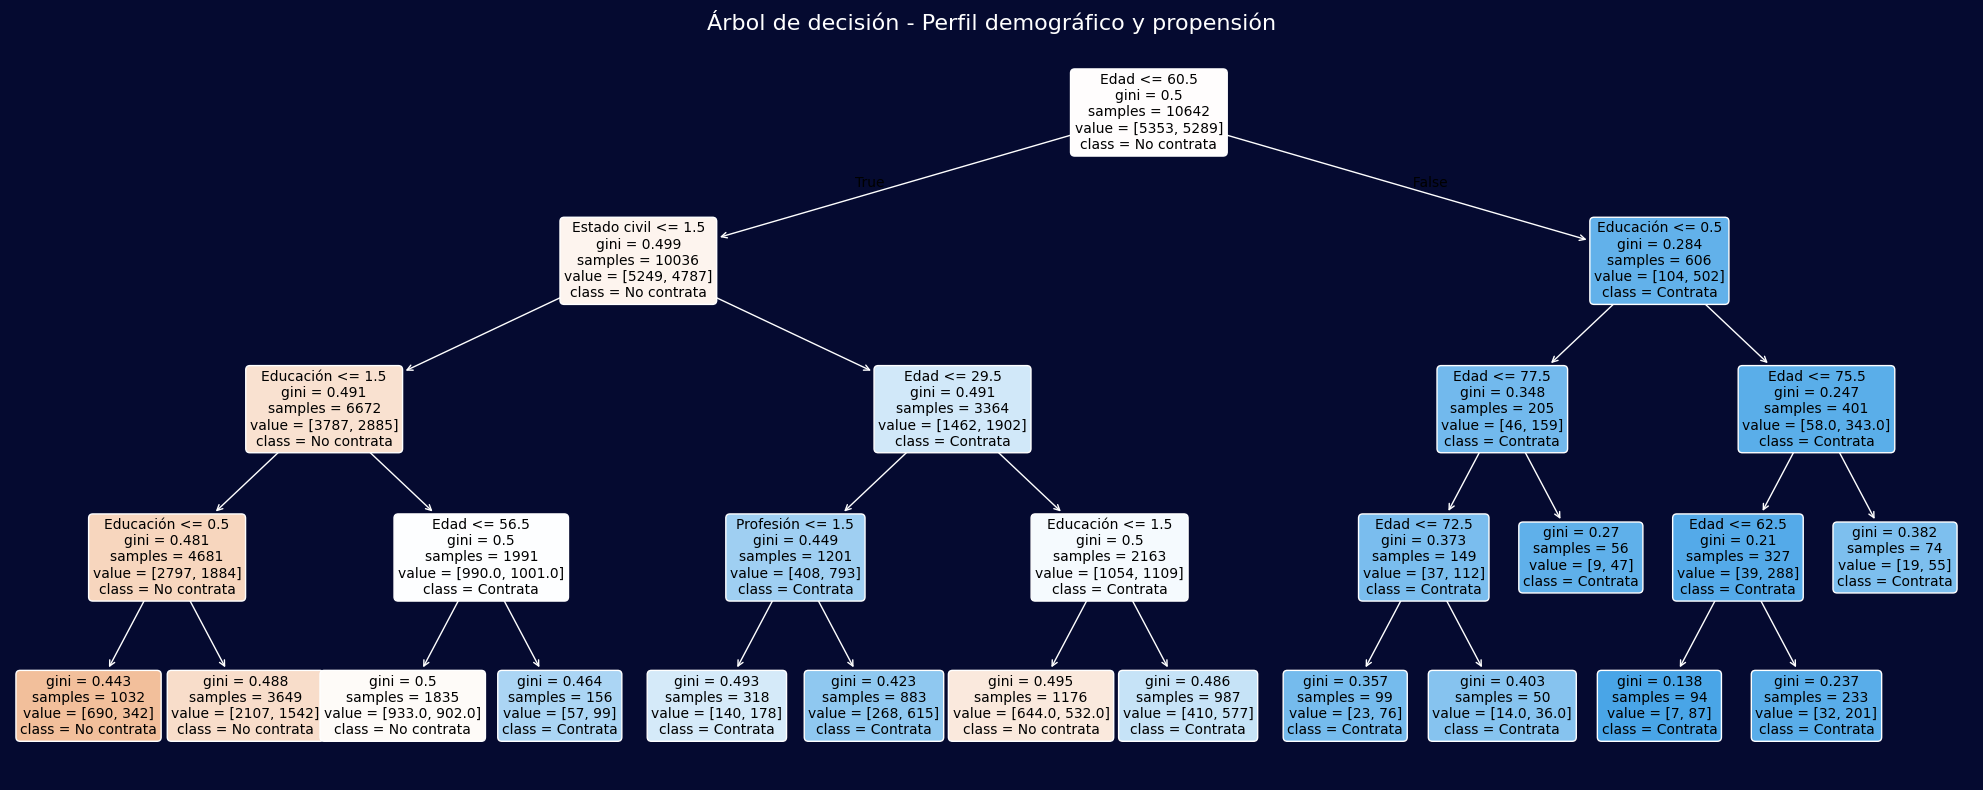

In [24]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

feature_names = ['Edad', 'Profesión', 'Estado civil', 'Educación']
class_names = ['No contrata', 'Contrata']

plt.figure(figsize=(20, 8), facecolor='#050a30')
ax = plt.gca()
ax.set_facecolor('#050a30')

plot_tree(
    arbol,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=10
)

# Ajustar colores del texto para que se vean en el fondo oscuro
for text in ax.texts:
    text.set_color('black') # El texto dentro de las cajas llenas suele ser mejor en negro o blanco según el color de la caja

plt.title('Árbol de decisión - Perfil demográfico y propensión', color='white', size=16)
plt.tight_layout()
plt.show()

## Árbol de decisión — Análisis complementario

El árbol de decisión confirma y enriquece los resultados del K-Prototypes, identificando las reglas demográficas más relevantes para predecir la contratación de productos financieros. El modelo alcanzó una precisión del **59,62%** sobre el conjunto de entrenamiento, lo que indica una capacidad predictiva aceptable considerando que solo se emplean variables demográficas, sin incluir información de comportamiento financiero o historial de contacto. 
Este valor confirma que la demografía tiene capacidad explicativa, aunque limitada, 
y justifica su uso como criterio de segmentación complementario al clustering.

A diferencia del clustering, el árbol:
- Usa `deposit` directamente como variable objetivo
- Genera reglas interpretables (por ejemplo: *"si edad > 60 → alta propensión"*)
- Muestra qué variable demográfica tiene más peso predictivo

Ambos métodos apuntan a los mismos perfiles: **personas mayores o jubiladas** y **perfiles profesionales de management** como los segmentos con mayor propensión.

A diferencia del clustering, el árbol:
- Usa `deposit` directamente como variable objetivo
- Genera reglas interpretables (por ejemplo: *"si edad > 60 → alta propensión"*)
- Muestra qué variable demográfica tiene más peso predictivo

Ambos métodos apuntan a los mismos perfiles: **personas mayores o jubiladas** 
y **perfiles profesionales de management** como los segmentos con mayor propensión.

--- 
## 16. Conclusión general
---

## Pregunta de investigación
*Quins són els perfils demogràfics que mostren més propensió a contractar 
productes financers?*

## Metodología
Se aplicaron dos enfoques complementarios sobre las variables demográficas 
disponibles (edad, profesión, estado civil y nivel educativo):

| Método | Tipo | Objetivo |
|---|---|---|
| K-Prototypes | No supervisado | Segmentar perfiles demográficos similares |
| Árbol de decisión | Supervisado | Identificar reglas predictivas de contratación |

## Resultados

### Perfiles con mayor propensión (ranking por tasa de conversión)

| Ranking | Perfil demográfico | Tasa de conversión |
|---|---|---|
| 1 | Jubilados · casados · ed. secundaria · ~61 años | 58.81% |
| 2 | Management · solteros · ed. terciaria · ~34 años | 56.10% |
| 3 | Técnicos · solteros · ed. secundaria · ~30 años | 50.43% |
| 4 | Blue-collar · casados · ed. secundaria · ~44 años | 40.24% |

### Convergencia entre métodos
Ambos métodos identifican los mismos perfiles prioritarios:

- **Personas jubiladas**: mayor tiempo disponible para gestionar sus finanzas 
  y mayor necesidad de instrumentos de ahorro o rentabilidad.
- **Perfiles de management jóvenes**: mayor formación financiera y capacidad 
  de ahorro, con interés en productos de inversión.

La variable **edad** resulta ser el predictor más relevante según el árbol 
de decisión, seguida de la profesión.

## Implicación práctica

Los segmentos 0 y 1 representan las audiencias prioritarias para campañas 
de marketing de productos de depósito bancario.

El segmento blue-collar (Cluster 2), aunque presenta la menor tasa de conversión 
en depósito, es el cluster con mayor vinculación financiera global al combinar 
hipoteca y préstamo personal. Por ello, no debe descartarse como segmento objetivo, 
sino abordarse con productos y mensajes adaptados a su perfil de crédito.

El segmento técnico joven (Cluster 3) representa una oportunidad intermedia 
con margen de crecimiento, especialmente en productos de ahorro a largo plazo.